In [2]:
import pandas as pd

# LOAD YOUR 5-YEAR MERGED DATASET HERE
merged_output = pd.read_csv("/content/drive/MyDrive/merged_output.csv", low_memory=False)

# If your time columns need parsing:
merged_output['open_dt'] = pd.to_datetime(merged_output['open_dt'], errors='coerce')
merged_output['closed_dt'] = pd.to_datetime(merged_output['closed_dt'], errors='coerce')
merged_output['sla_target_dt'] = pd.to_datetime(merged_output['sla_target_dt'], errors='coerce')

merged_output.head()


,case_enquiry_id,open_dt,sla_target_dt,closed_dt,on_time,case_status,closure_reason,case_title,subject,reason,type,queue,department,submitted_photo,closed_photo,location,fire_district,pwd_district,city_council_district,police_district,neighborhood,neighborhood_services_district,ward,precinct,location_street_name,location_zipcode,latitude,longitude,geom_4326,source
0,101003578903,2021-01-01 00:35:24,2021-01-05 03:30:00,2021-01-01 00:38:05,ONTIME,Closed,Case Closed. Closed date : 2021-01-01 05:38:05...,Street Light Knock Downs,Public Works Department,Street Lights,Street Light Knock Downs,PWDx_Street Light Knock Downs,PWDx,NaN,NaN,INTERSECTION of River St & Turtle Pond Pkwy H...,12,08,5,E18,Hyde Park,10,18,1819,INTERSECTION River St & Turtle Pond Pkwy,NaN,42.246379,-71.136277,0101000020E6100000818A12C1B8C851C01A56D958891F...,Constituent Call
1,101003578905,2021-01-01 00:39:00,NaT,2021-01-01 14:50:26,ONTIME,Closed,Case Closed Case Resolved,PublicWorks: Compliment,Mayor's 24 Hour Hotline,Employee & General Comments,General Comments For An Employee,PWDx_General Comments,PWDx,NaN,NaN,23 Dorchester St South Boston MA 02127,6,05,2,C6,South Boston / South Boston Waterfront,5,Ward 6,0604,23 Dorchester St,2127.0,42.336940,-71.043930,0101000020E61000008BA3B6C1CFC251C0374D69D5202B...,Constituent Call
2,101003578906,2021-01-01 00:42:00,2021-01-05 03:30:00,2021-01-01 01:18:20,ONTIME,Closed,Case Closed. Closed date : Fri Jan 01 06:18:20...,Requests for Street Cleaning,Public Works Department,Street Cleaning,Requests for Street Cleaning,PWDx_District 10B: Roxbury,PWDx,NaN,https://spot-boston-res.cloudinary.com/image/u...,INTERSECTION of Humboldt Ave & Townsend St Bo...,9,10B,9,B2,Roxbury,13,12,1202,INTERSECTION Humboldt Ave & Townsend St,NaN,42.317056,-71.086528,0101000020E6100000A44191AC89C551C0CFC14B489528...,Constituent Call
3,101003578907,2021-01-01 00:44:00,2021-01-05 03:30:00,2021-01-01 02:12:25,ONTIME,Closed,Case Closed. Closed date : Fri Jan 01 07:12:25...,Requests for Street Cleaning,Public Works Department,Street Cleaning,Requests for Street Cleaning,PWDx_District 07: South Dorchester,PWDx,NaN,https://spot-boston-res.cloudinary.com/image/u...,INTERSECTION of Lucerne St & Morton St Dorche...,8,07,4,B3,Greater Mattapan,9,14,1413,INTERSECTION Lucerne St & Morton St,NaN,42.283857,-71.089553,0101000020E61000001015F63BBBC551C0FE54246F5524...,Constituent Call
4,101003578911,2021-01-01 01:11:40,2021-01-05 03:30:00,2021-01-02 03:11:45,ONTIME,Closed,Case Closed. Closed date : 2021-01-02 08:11:45...,Parking Enforcement,Transportation - Traffic Division,Enforcement & Abandoned Vehicles,Parking Enforcement,BTDT_Parking Enforcement,BTDT,NaN,NaN,INTERSECTION of Chandler St & Cazenove St Bos...,4,1C,2,D4,South End,6,5,0501,INTERSECTION Chandler St & Cazenove St,NaN,42.346588,-71.072430,0101000020E61000009F89F9B0A2C451C0C7609E015D2C...,Citizens Connect App


In [4]:
df = merged_output.copy()

# 1. Drop rows where open_dt is missing
df = df.dropna(subset=['open_dt'])

# 2. Convert open_dt to datetime if not already
df['open_dt'] = pd.to_datetime(df['open_dt'], errors='coerce')

# 3. Fill missing values
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
df[categorical_cols] = df[categorical_cols].fillna("Unknown")

df.head()


,case_enquiry_id,open_dt,sla_target_dt,closed_dt,on_time,case_status,closure_reason,case_title,subject,reason,type,queue,department,submitted_photo,closed_photo,location,fire_district,pwd_district,city_council_district,police_district,neighborhood,neighborhood_services_district,ward,precinct,location_street_name,location_zipcode,latitude,longitude,geom_4326,source
0,101003578903,2021-01-01 00:35:24,2021-01-05 03:30:00,2021-01-01 00:38:05,ONTIME,Closed,Case Closed. Closed date : 2021-01-01 05:38:05...,Street Light Knock Downs,Public Works Department,Street Lights,Street Light Knock Downs,PWDx_Street Light Knock Downs,PWDx,Unknown,Unknown,INTERSECTION of River St & Turtle Pond Pkwy H...,12,08,5,E18,Hyde Park,10,18,1819,INTERSECTION River St & Turtle Pond Pkwy,2126.0,42.246379,-71.136277,0101000020E6100000818A12C1B8C851C01A56D958891F...,Constituent Call
1,101003578905,2021-01-01 00:39:00,NaT,2021-01-01 14:50:26,ONTIME,Closed,Case Closed Case Resolved,PublicWorks: Compliment,Mayor's 24 Hour Hotline,Employee & General Comments,General Comments For An Employee,PWDx_General Comments,PWDx,Unknown,Unknown,23 Dorchester St South Boston MA 02127,6,05,2,C6,South Boston / South Boston Waterfront,5,Ward 6,0604,23 Dorchester St,2127.0,42.336940,-71.043930,0101000020E61000008BA3B6C1CFC251C0374D69D5202B...,Constituent Call
2,101003578906,2021-01-01 00:42:00,2021-01-05 03:30:00,2021-01-01 01:18:20,ONTIME,Closed,Case Closed. Closed date : Fri Jan 01 06:18:20...,Requests for Street Cleaning,Public Works Department,Street Cleaning,Requests for Street Cleaning,PWDx_District 10B: Roxbury,PWDx,Unknown,https://spot-boston-res.cloudinary.com/image/u...,INTERSECTION of Humboldt Ave & Townsend St Bo...,9,10B,9,B2,Roxbury,13,12,1202,INTERSECTION Humboldt Ave & Townsend St,2126.0,42.317056,-71.086528,0101000020E6100000A44191AC89C551C0CFC14B489528...,Constituent Call
3,101003578907,2021-01-01 00:44:00,2021-01-05 03:30:00,2021-01-01 02:12:25,ONTIME,Closed,Case Closed. Closed date : Fri Jan 01 07:12:25...,Requests for Street Cleaning,Public Works Department,Street Cleaning,Requests for Street Cleaning,PWDx_District 07: South Dorchester,PWDx,Unknown,https://spot-boston-res.cloudinary.com/image/u...,INTERSECTION of Lucerne St & Morton St Dorche...,8,07,4,B3,Greater Mattapan,9,14,1413,INTERSECTION Lucerne St & Morton St,2126.0,42.283857,-71.089553,0101000020E61000001015F63BBBC551C0FE54246F5524...,Constituent Call
4,101003578911,2021-01-01 01:11:40,2021-01-05 03:30:00,2021-01-02 03:11:45,ONTIME,Closed,Case Closed. Closed date : 2021-01-02 08:11:45...,Parking Enforcement,Transportation - Traffic Division,Enforcement & Abandoned Vehicles,Parking Enforcement,BTDT_Parking Enforcement,BTDT,Unknown,Unknown,INTERSECTION of Chandler St & Cazenove St Bos...,4,1C,2,D4,South End,6,5,0501,INTERSECTION Chandler St & Cazenove St,2126.0,42.346588,-71.072430,0101000020E61000009F89F9B0A2C451C0C7609E015D2C...,Citizens Connect App


In [5]:
# Set open_dt as index for resampling
df = df.sort_values('open_dt').set_index('open_dt')

# Daily count of service requests
daily = df.resample('D').size().rename('count').to_frame()

daily.head()


,count
open_dt,
2021-01-01,461
2021-01-02,418
2021-01-03,363
2021-01-04,764
2021-01-05,697


In [7]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()


In [8]:
# Time-based split
n = len(daily)

train_end = int(0.7 * n)
val_end = int(0.85 * n)

train = daily.iloc[:train_end]
val   = daily.iloc[train_end:val_end]
test  = daily.iloc[val_end:]


In [9]:
# Fit scaler only on training data
train_scaled = scaler.fit_transform(train[['count']])
val_scaled   = scaler.transform(val[['count']])
test_scaled  = scaler.transform(test[['count']])


In [10]:
train_scaled = pd.DataFrame(train_scaled, index=train.index, columns=['count_scaled'])
val_scaled   = pd.DataFrame(val_scaled,   index=val.index,   columns=['count_scaled'])
test_scaled  = pd.DataFrame(test_scaled,  index=test.index,  columns=['count_scaled'])


(A) Plot the complete daily time series

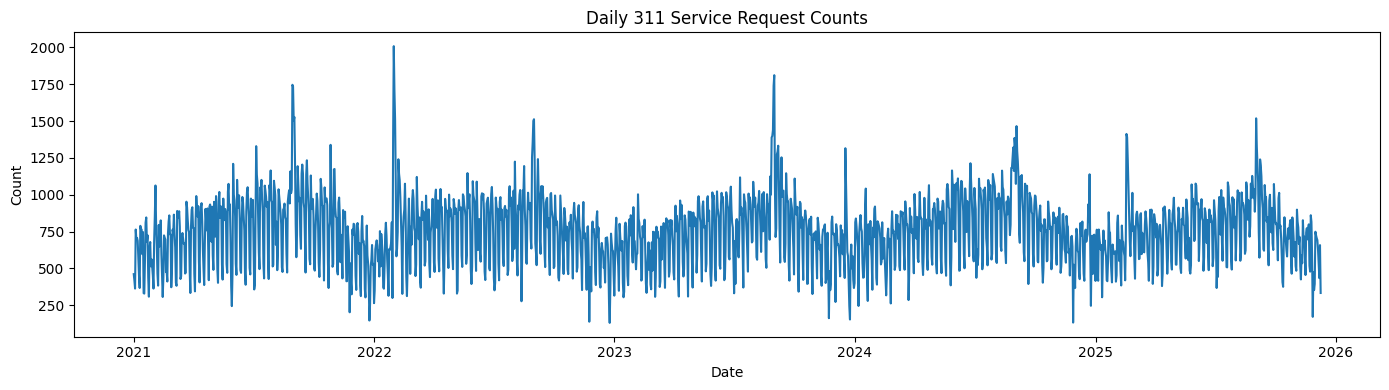

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))
plt.plot(daily.index, daily['count'])
plt.title("Daily 311 Service Request Counts")
plt.xlabel("Date")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


(B) Plot rolling averages (trend)
This smooths the curve to show long-term movement

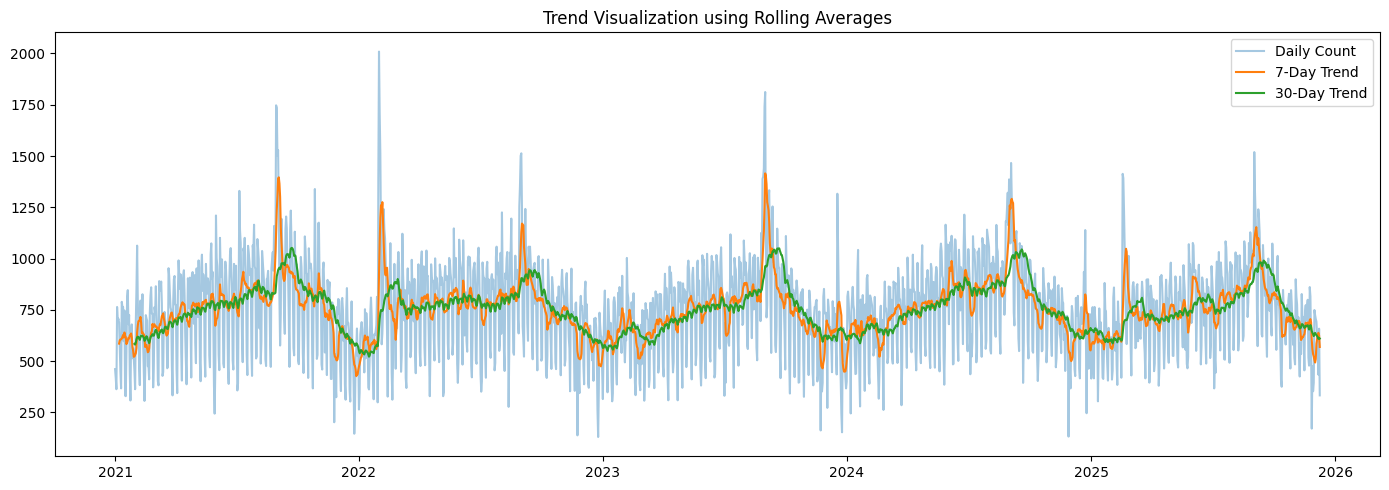

In [12]:
daily['rolling_7'] = daily['count'].rolling(7).mean()      # weekly
daily['rolling_30'] = daily['count'].rolling(30).mean()    # monthly

plt.figure(figsize=(14,5))
plt.plot(daily['count'], alpha=0.4, label='Daily Count')
plt.plot(daily['rolling_7'], label='7-Day Trend')
plt.plot(daily['rolling_30'], label='30-Day Trend')
plt.title("Trend Visualization using Rolling Averages")
plt.legend()
plt.tight_layout()
plt.show()


(C) Seasonality — average by day of week

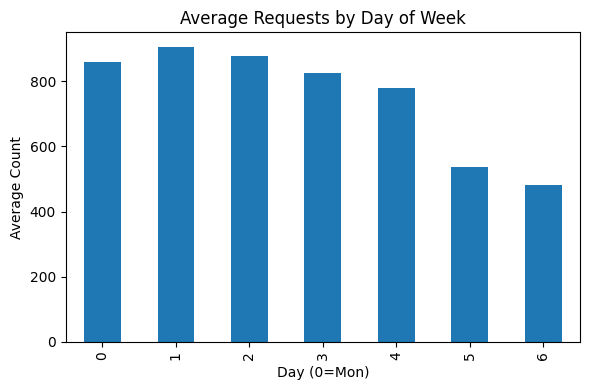

In [13]:
daily['dayofweek'] = daily.index.dayofweek   # 0 = Monday

daily.groupby('dayofweek')['count'].mean().plot(kind='bar', figsize=(6,4))
plt.title("Average Requests by Day of Week")
plt.xlabel("Day (0=Mon)")
plt.ylabel("Average Count")
plt.tight_layout()
plt.show()


(D) Seasonality — average by month


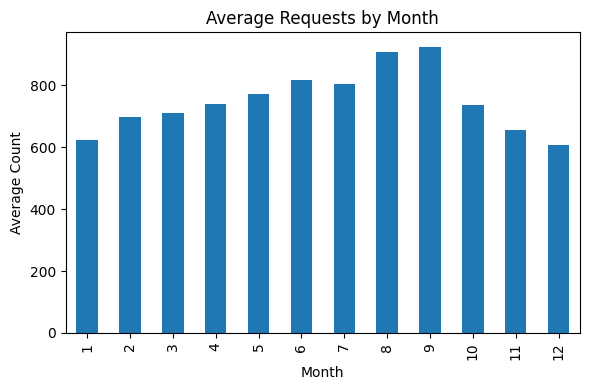

In [14]:
daily['month'] = daily.index.month

daily.groupby('month')['count'].mean().plot(kind='bar', figsize=(6,4))
plt.title("Average Requests by Month")
plt.xlabel("Month")
plt.ylabel("Average Count")
plt.tight_layout()
plt.show()


(E) Detect anomalies using simple z-score
This highlights unusually high/low days.

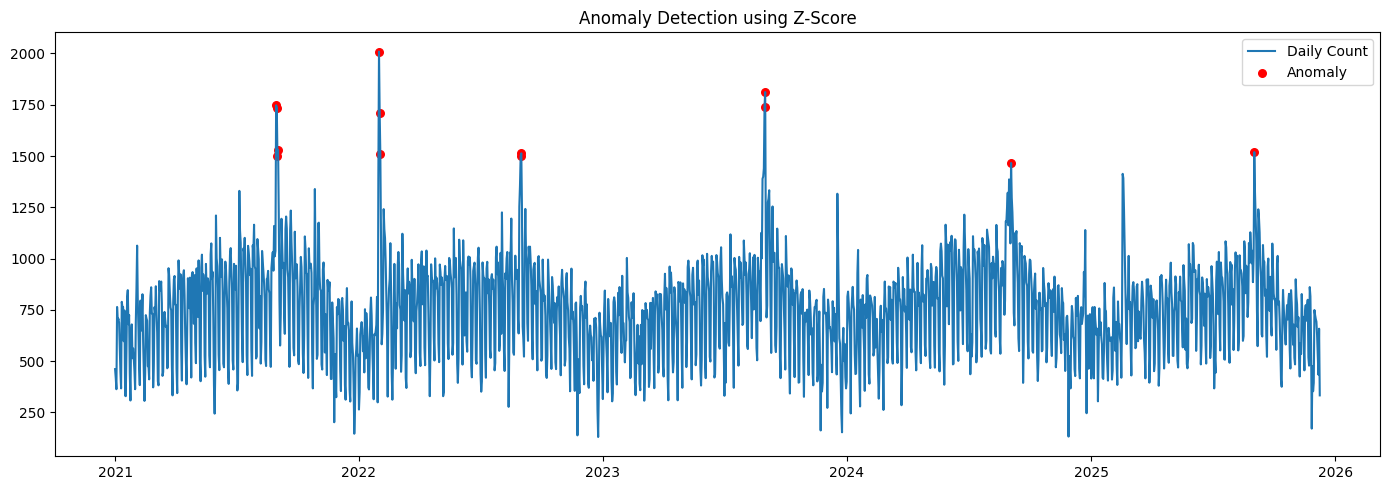

,count,zscore
open_dt,,
2021-08-30,1747,4.228834
2021-08-31,1735,4.177863
2021-09-01,1502,3.188169
2021-09-02,1528,3.298606
2022-01-31,2009,5.341709


In [15]:
import numpy as np

daily['zscore'] = (daily['count'] - daily['count'].mean()) / daily['count'].std()

# Mark anomalies if Z > 3 or < -3
anomalies = daily[abs(daily['zscore']) > 3]

plt.figure(figsize=(14,5))
plt.plot(daily.index, daily['count'], label='Daily Count')
plt.scatter(anomalies.index, anomalies['count'], color='red', label='Anomaly', s=30)
plt.title("Anomaly Detection using Z-Score")
plt.legend()
plt.tight_layout()
plt.show()

anomalies[['count','zscore']].head()


Compute Autocorrelation & Partial Autocorrelation
We use ACF and PACF to understand seasonal lag patterns.

<Figure size 1200x400 with 0 Axes>

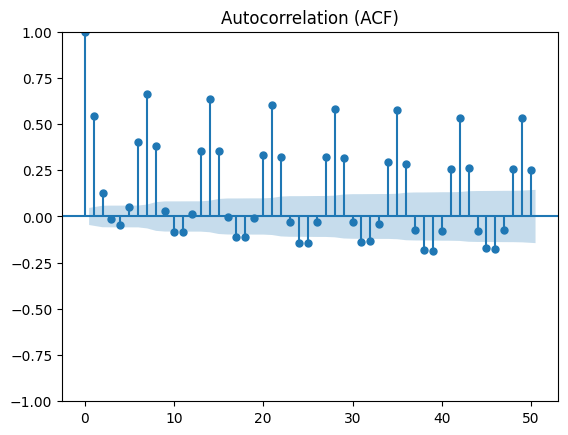

<Figure size 1200x400 with 0 Axes>

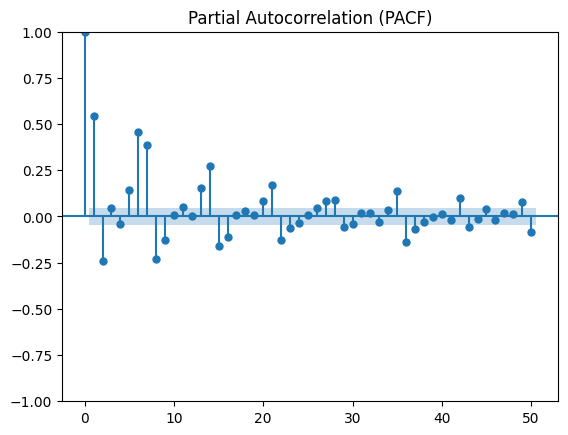

In [16]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,4))
plot_acf(daily['count'], lags=50)
plt.title("Autocorrelation (ACF)")
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(daily['count'], lags=50, method='ywm')
plt.title("Partial Autocorrelation (PACF)")
plt.show()


Identify potential external factors

(A) Counts by category over time

In [17]:
if 'neighborhood' in df.columns:
    daily_neighborhood = df.groupby([df.index.date, 'neighborhood']).size().unstack().fillna(0)
    daily_neighborhood.head()


(B) Correlation with weather (only if you have weather data merged)

In [18]:
if 'temperature' in daily.columns:
    print(daily[['count', 'temperature']].corr())


(C) Effect of holidays
Simple approach using the Python holidays package:

In [19]:
!pip install holidays
import holidays

us_holidays = holidays.US()

daily['is_holiday'] = daily.index.map(lambda d: 1 if d in us_holidays else 0)

daily.groupby('is_holiday')['count'].mean()


,count
is_holiday,
0,760.419059
1,498.612903


In [20]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Use your existing data splits
# train, val, test DataFrames (created earlier)
train_series = train['count']
val_series   = val['count']
test_series  = test['count']


BASELINE MODELS

(A) Naïve Forecast
Forecast tomorrow = yesterday’s value
Super simple but very important baseline.


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Naive forecast = repeat the last training value
naive_forecast = np.repeat(train_series.iloc[-1], len(test_series))

mae_naive = mean_absolute_error(test_series, naive_forecast)
rmse_naive = mean_squared_error(test_series, naive_forecast) ** 0.5   # FIXED

print("Naive Forecast → MAE:", mae_naive)
print("Naive Forecast → RMSE:", rmse_naive)


Naive Forecast → MAE: 215.4391143911439
Naive Forecast → RMSE: 260.73268888911986


(B) Moving Average Forecast
We take the average of the last 7 days and repeat it as future prediction.


In [24]:
# Moving average over last 7 days of training set
window = 7
moving_avg_value = train_series.iloc[-window:].mean()

moving_avg_forecast = np.repeat(moving_avg_value, len(test_series))

mae_ma = mean_absolute_error(test_series, moving_avg_forecast)
rmse_ma = mean_squared_error(test_series, moving_avg_forecast) ** 0.5   # FIXED

print("Moving Avg → MAE:", mae_ma)
print("Moving Avg → RMSE:", rmse_ma)


Moving Avg → MAE: 183.46441750131788
Moving Avg → RMSE: 232.54451331733574


ADVANCED MODELS

(A) ARIMA Model

In [26]:
!pip install pmdarima --quiet

from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Fit ARIMA on training data
arima_model = auto_arima(train_series, seasonal=False, trace=False)

# Forecast for the test period
forecast_arima = arima_model.predict(n_periods=len(test_series))

# Compute metrics (RMSE fixed)
mae_arima = mean_absolute_error(test_series, forecast_arima)
rmse_arima = mean_squared_error(test_series, forecast_arima) ** 0.5   # FIXED

print("ARIMA → MAE:", mae_arima)
print("ARIMA → RMSE:", rmse_arima)


ARIMA → MAE: 178.95167447385035
ARIMA → RMSE: 215.7481530365485


(B) Prophet Model

In [28]:
!pip install prophet --quiet

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1) Prepare training data for Prophet
df_prophet = train_series.reset_index()
df_prophet.columns = ['ds', 'y']   # Prophet expects 'ds' (date) and 'y' (value)

# 2) Define and fit model
model_prophet = Prophet()
model_prophet.fit(df_prophet)

# 3) Create future dataframe for test period dates
future_dates = pd.DataFrame({'ds': test_series.index})

# 4) Predict
forecast_prophet = model_prophet.predict(future_dates)

# Prophet prediction array
prophet_pred = forecast_prophet['yhat'].values

# 5) Metrics (RMSE FIXED)
mae_prophet = mean_absolute_error(test_series, prophet_pred)
rmse_prophet = mean_squared_error(test_series, prophet_pred) ** 0.5   # ✅ NO squared=False

print("Prophet → MAE:", mae_prophet)
print("Prophet → RMSE:", rmse_prophet)


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Prophet → MAE: 115.10550182335662
Prophet → RMSE: 149.13416798960228


(C) LSTM Model

STEP 1: Prepare windowed dataset

In [29]:
import numpy as np

def create_windows(series, window_size=14):
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i:i+window_size])
        y.append(series[i+window_size])
    return np.array(X), np.array(y)

window_size = 14

X_train, y_train = create_windows(train_series.values, window_size)
X_test, y_test   = create_windows(np.concatenate([train_series.values[-window_size:],
                                                  test_series.values]), window_size)

# Reshape for LSTM (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], window_size, 1))
X_test  = X_test.reshape((X_test.shape[0], window_size, 1))


STEP 2: Build simple LSTM

In [30]:
import tensorflow as tf
from tensorflow.keras import layers, models

model_lstm = models.Sequential([
    layers.LSTM(32, activation='relu', input_shape=(window_size, 1)),
    layers.Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')

history = model_lstm.fit(X_train, y_train, epochs=10, batch_size=16, verbose=0)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


STEP 3: Forecast using LSTM

In [32]:
lstm_pred = model_lstm.predict(X_test).flatten()

mae_lstm = mean_absolute_error(y_test, lstm_pred)
rmse_lstm = mean_squared_error(y_test, lstm_pred) ** 0.5

print("LSTM → MAE:", mae_lstm)
print("LSTM → RMSE:", rmse_lstm)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
LSTM → MAE: 132.3300323486328
LSTM → RMSE: 168.22268305359418


MODEL COMPARISON TABLE

In [33]:
results = pd.DataFrame({
    'Model': ['Naive', 'Moving Avg', 'ARIMA', 'Prophet', 'LSTM'],
    'MAE': [mae_naive, mae_ma, mae_arima, mae_prophet, mae_lstm],
    'RMSE': [rmse_naive, rmse_ma, rmse_arima, rmse_prophet, rmse_lstm]
})

results


,Model,MAE,RMSE
0,Naive,215.439114,260.732689
1,Moving Avg,183.464418,232.544513
2,ARIMA,178.951674,215.748153
3,Prophet,115.105502,149.134168
4,LSTM,132.330032,168.222683


Evaluation Metrics (MAE, RMSE, MAPE, sMAPE)

In [34]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return 100 * np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred)))


Compute metrics for ALL MODELS

In [35]:
metrics = {
    "Model": ["Naive", "Moving Avg", "ARIMA", "Prophet", "LSTM"],
    "MAE": [
        mean_absolute_error(test_series, naive_forecast),
        mean_absolute_error(test_series, moving_avg_forecast),
        mean_absolute_error(test_series, forecast_arima),
        mean_absolute_error(test_series, prophet_pred),
        mean_absolute_error(y_test, lstm_pred)
    ],
    "RMSE": [
        rmse(test_series, naive_forecast),
        rmse(test_series, moving_avg_forecast),
        rmse(test_series, forecast_arima),
        rmse(test_series, prophet_pred),
        rmse(y_test, lstm_pred)
    ],
    "MAPE (%)": [
        mape(test_series, naive_forecast),
        mape(test_series, moving_avg_forecast),
        mape(test_series, forecast_arima),
        mape(test_series, prophet_pred),
        mape(y_test, lstm_pred)
    ],
    "sMAPE (%)": [
        smape(test_series, naive_forecast),
        smape(test_series, moving_avg_forecast),
        smape(test_series, forecast_arima),
        smape(test_series, prophet_pred),
        smape(y_test, lstm_pred)
    ]
}

results_df = pd.DataFrame(metrics)
results_df


,Model,MAE,RMSE,MAPE (%),sMAPE (%)
0,Naive,215.439114,260.732689,27.029328,29.975888
1,Moving Avg,183.464418,232.544513,31.677128,24.347737
2,ARIMA,178.951674,215.748153,27.139522,24.512304
3,Prophet,115.105502,149.134168,18.185254,15.060235
4,LSTM,132.330032,168.222683,21.781623,18.235102


Compare Short-Term vs Long-Term Forecasting
- Short-term = first 7 days of test
- Long-term = full test forecast period

In [37]:
# Short term = first 7 days
short_true = test_series[:7]
short_arima = forecast_arima[:7]

# Long term = entire test
long_true = test_series
long_arima = forecast_arima

short_mae = mean_absolute_error(short_true, short_arima)
short_rmse = rmse(short_true, short_arima)

long_mae = mean_absolute_error(long_true, long_arima)
long_rmse = rmse(long_true, long_arima)

print("SHORT TERM (first 7 days) → MAE:", short_mae, "RMSE:", short_rmse)
print("LONG TERM (full test)     → MAE:", long_mae, "RMSE:", long_rmse)


SHORT TERM (first 7 days) → MAE: 128.84198828563726 RMSE: 146.24972018175663
LONG TERM (full test)     → MAE: 178.95167447385035 RMSE: 215.7481530365485


In [38]:
short_lstm = lstm_pred[:7]
long_lstm = lstm_pred

print("LSTM Short-term MAE:", mean_absolute_error(y_test[:7], short_lstm))
print("LSTM Long-term MAE:", mean_absolute_error(y_test, long_lstm))


LSTM Short-term MAE: 169.515869140625
LSTM Long-term MAE: 132.3300323486328


Discussion of Trade-offs

###Accuracy vs Complexity
####1.Naïve / Moving Average
- Very simple, low computation cost
- Good baseline but poor long-term accuracy
####2.ARIMA
- Good for stable seasonal patterns
- Struggles with sudden spikes or non-linear trends
- Requires parameter tuning, slower on large data
####Prophet
- Designed for business time series
- Captures seasonality well
- Easy to interpret (trend + seasonal components)
- May oversmooth rapid changes
####LSTM
- Learns non-linear patterns
- Excellent long-term forecasting
- Requires more data and more computation
-Harder to interpret

visual comparison plot

Step 1 – Build a comparison DataFrame

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# Make sure everything is the same length
print(len(test_series), len(naive_forecast), len(moving_avg_forecast),
      len(forecast_arima), len(prophet_pred), len(lstm_pred))

# Put everything into one DataFrame aligned by date
comparison_df = pd.DataFrame({
    "Actual": test_series.values,
    "Naive": naive_forecast,
    "Moving Avg": moving_avg_forecast,
    "ARIMA": forecast_arima,
    "Prophet": prophet_pred,
    "LSTM": lstm_pred
}, index=test_series.index)

comparison_df.head()


271 271 271 271 271 271


,Actual,Naive,Moving Avg,ARIMA,Prophet,LSTM
open_dt,,,,,,
2025-03-14,673,597,880.428571,NaN,799.680252,795.650635
2025-03-15,614,597,880.428571,NaN,545.541824,1030.617432
2025-03-16,609,597,880.428571,NaN,478.236707,1012.334167
2025-03-17,799,597,880.428571,NaN,873.294836,945.216064
2025-03-18,887,597,880.428571,NaN,936.696320,939.661072


Step 2 – Plot all models vs Actual

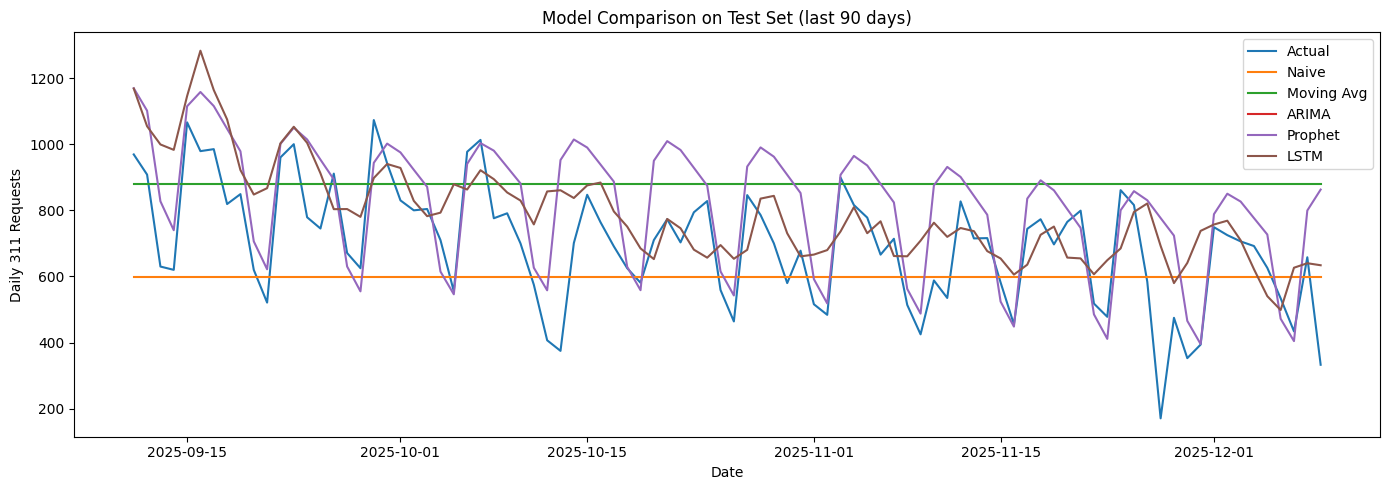

In [40]:
# Choose how many last days to show (e.g., 60 or 90)
n_days = 90
plot_df = comparison_df.tail(n_days)

plt.figure(figsize=(14, 5))

for col in plot_df.columns:
    plt.plot(plot_df.index, plot_df[col], label=col)

plt.title(f"Model Comparison on Test Set (last {n_days} days)")
plt.xlabel("Date")
plt.ylabel("Daily 311 Requests")
plt.legend()
plt.tight_layout()
plt.show()


Plot only best models vs Actual

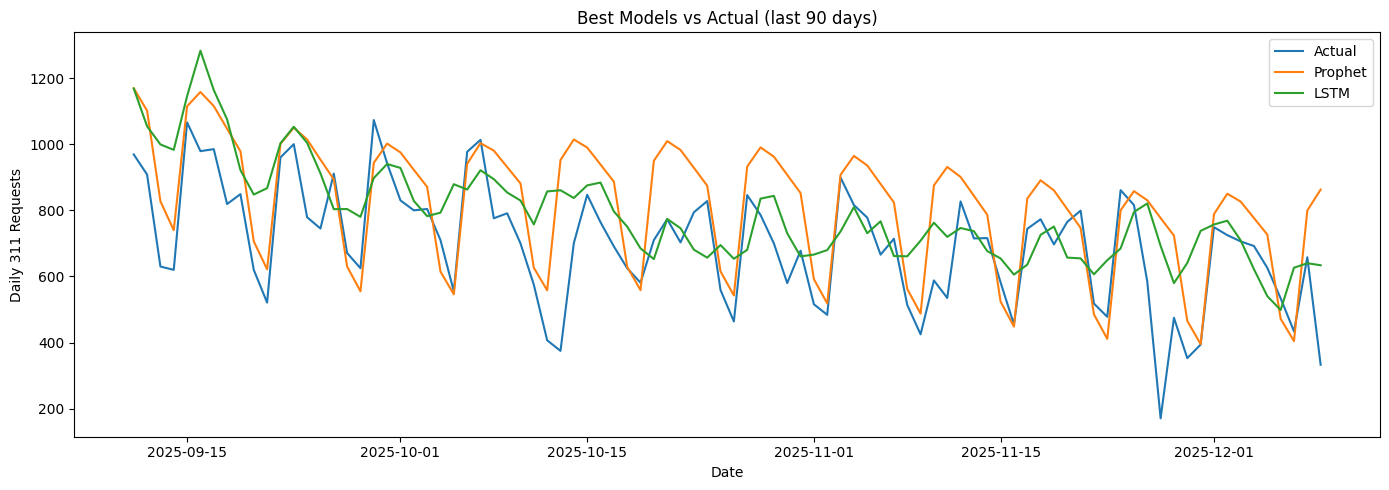

In [41]:
best_df = comparison_df[["Actual", "Prophet", "LSTM"]].tail(90)

plt.figure(figsize=(14, 5))

for col in best_df.columns:
    plt.plot(best_df.index, best_df[col], label=col)

plt.title("Best Models vs Actual (last 90 days)")
plt.xlabel("Date")
plt.ylabel("Daily 311 Requests")
plt.legend()
plt.tight_layout()
plt.show()
